# Pakistan 24K Gold Price — Dynamic ML Forecasting Pipeline

**Gold.pk → Excel update → cleaning → EDA → feature engineering → chronological split → ML/time-series models → evaluation → model selection → DatePicker → recursive forecast → graph → Excel export**

The notebook uses the latest actual date automatically, prevents duplicate daily observations, and lets you choose the forecast end date without hardcoding it.

## 1. Install core dependencies

Run the first cell once. Optional packages are handled later and are skipped if unavailable.

In [1]:
# %pip install -q pandas numpy matplotlib seaborn scikit-learn openpyxl requests statsmodels ipywidgets
# %pip install html5lib

In [2]:
# Optional models, if required:
# %pip install -q xgboost catboost prophet tensorflow

## 2. Imports and configuration

In [3]:
import warnings, re, importlib.util
from pathlib import Path
from datetime import datetime
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, RANSACRegressor, PoissonRegressor, QuantileRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

GOLD_PK_URL = "https://gold.pk/"
DATA_PATTERN = "Pakistan_Gold_Daily_Regression_*.xlsx"
SHEET_NAME = "Daily_Regression"
TARGET = "24K_PKR_per_Tola"
RANDOM_STATE = 42
print("Environment ready.")

Environment ready.


## 3. Find the existing Gold Excel dataset automatically

In [4]:
def find_gold_excel():
    files = sorted(Path(".").glob(DATA_PATTERN), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No Excel file matching {DATA_PATTERN} was found.")
    return files[0]

def extract_number(value):
    value = re.sub(r"[^0-9.]", "", str(value))
    return float(value) if value else np.nan

file_path = find_gold_excel()
print("Using:", file_path)

Using: Pakistan_Gold_Daily_Regression_2025_to_2026-09-01.xlsx


## 4. Fetch the latest daily 24K closing rate from Gold.pk

In [5]:
def fetch_latest_gold_pk_rate():
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/154.0 Safari/537.36"}
    r = requests.get(GOLD_PK_URL, headers=headers, timeout=20)
    r.raise_for_status()
    tables = pd.read_html(r.text)

    for t in tables:
        dcols = [c for c in t.columns if "date" in str(c).lower()]
        ccols = [c for c in t.columns if "closing" in str(c).lower()]
        if not dcols or not ccols:
            continue
        d, c = dcols[0], ccols[0]
        t["Parsed_Date"] = pd.to_datetime(t[d], errors="coerce")
        t["Parsed_Close"] = t[c].apply(extract_number)
        t = t.dropna(subset=["Parsed_Date", "Parsed_Close"])
        if not t.empty:
            row = t.sort_values("Parsed_Date").iloc[-1]
            return {
                "Date": pd.Timestamp(row["Parsed_Date"]).normalize(),
                TARGET: float(row["Parsed_Close"]),
                "Source": "Gold.pk",
                "Retrieved_At": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            }
    raise ValueError("Gold.pk daily closing-rate table was not found.")

## 5. Update Excel without duplicate dates

In [6]:
def update_gold_excel(path):
    data = pd.read_excel(path, sheet_name=SHEET_NAME)
    if "Date" not in data.columns or TARGET not in data.columns:
        raise ValueError(f"Sheet must contain Date and {TARGET} columns.")

    data["Date"] = pd.to_datetime(data["Date"], errors="coerce").dt.normalize()
    data[TARGET] = pd.to_numeric(data[TARGET], errors="coerce")

    try:
        latest = fetch_latest_gold_pk_rate()
        print("Gold.pk latest:", latest["Date"].date(), "|", latest[TARGET], "PKR/tola")

        if latest["Date"] in set(data["Date"].dropna()):
            print("Date already exists. No duplicate added.")
            return path

        old = data[data["Date"] < latest["Date"]].sort_values("Date")
        previous = old[TARGET].iloc[-1] if not old.empty else np.nan
        row = {c: np.nan for c in data.columns}
        row["Date"], row[TARGET] = latest["Date"], latest[TARGET]

        if "Daily_Change_PKR" in data.columns:
            row["Daily_Change_PKR"] = latest[TARGET] - previous if pd.notna(previous) else np.nan
        if "Daily_Change_Pct" in data.columns:
            row["Daily_Change_Pct"] = ((latest[TARGET]-previous)/previous)*100 if pd.notna(previous) and previous != 0 else np.nan
        if "Day_of_Week" in data.columns: row["Day_of_Week"] = latest["Date"].day_name()
        if "Day_of_Week_Num" in data.columns: row["Day_of_Week_Num"] = latest["Date"].dayofweek
        if "Is_Observed" in data.columns: row["Is_Observed"] = 1
        if "Source" in data.columns: row["Source"] = latest["Source"]
        if "Retrieved_At" in data.columns: row["Retrieved_At"] = latest["Retrieved_At"]

        data = pd.concat([data, pd.DataFrame([row])], ignore_index=True)
        data = data.sort_values("Date").drop_duplicates("Date", keep="last").reset_index(drop=True)
        with pd.ExcelWriter(path, engine="openpyxl", mode="w") as writer:
            data.to_excel(writer, sheet_name=SHEET_NAME, index=False)
        print("New observation added.")
    except Exception as e:
        print("WARNING: Gold.pk update failed:", e)
        print("Existing Excel data will be used unchanged.")
    return path

file_path = update_gold_excel(file_path)
df = pd.read_excel(file_path, sheet_name=SHEET_NAME)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce").dt.normalize()
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
print("Dataset:", len(df), "rows | latest:", df["Date"].max().date())

Existing Excel data will be used unchanged.
Dataset: 632 rows | latest: 2026-09-24


## 6. Cleaning and quality checks

In [7]:
df = df.dropna(subset=["Date", TARGET]).sort_values("Date")
df = df.drop_duplicates("Date", keep="last").reset_index(drop=True)
print("Rows:", len(df))
print("Date range:", df.Date.min().date(), "to", df.Date.max().date())
print("Duplicate dates:", df.Date.duplicated().sum())
display(df.isna().sum().to_frame("Missing"))
display(df.tail())

Rows: 632
Date range: 2025-01-01 to 2026-09-24
Duplicate dates: 0


,Missing
Date,0
Day_of_Week,0
Day_of_Week_Num,0
24K_PKR_per_Tola,0
24K_Daily_Change_PKR,0
24K_Daily_Change_Pct,0
Is_Observed,0
Fill_Basis_Date,0


,Date,Day_of_Week,Day_of_Week_Num,24K_PKR_per_Tola,24K_Daily_Change_PKR,24K_Daily_Change_Pct,Is_Observed,Fill_Basis_Date
627,2026-09-20,Sunday,7,454700,0,0.000000,0,2026-09-20
628,2026-09-21,Monday,1,453300,-1400,-0.003079,1,2026-09-21
629,2026-09-22,Tuesday,2,451800,-1500,-0.003309,1,2026-09-22
630,2026-09-23,Wednesday,3,450300,-1500,-0.003320,1,2026-09-23
631,2026-09-24,Thursday,4,448300,-2000,-0.004441,1,2026-09-24


## 7. EDA — trend, rolling averages and daily change

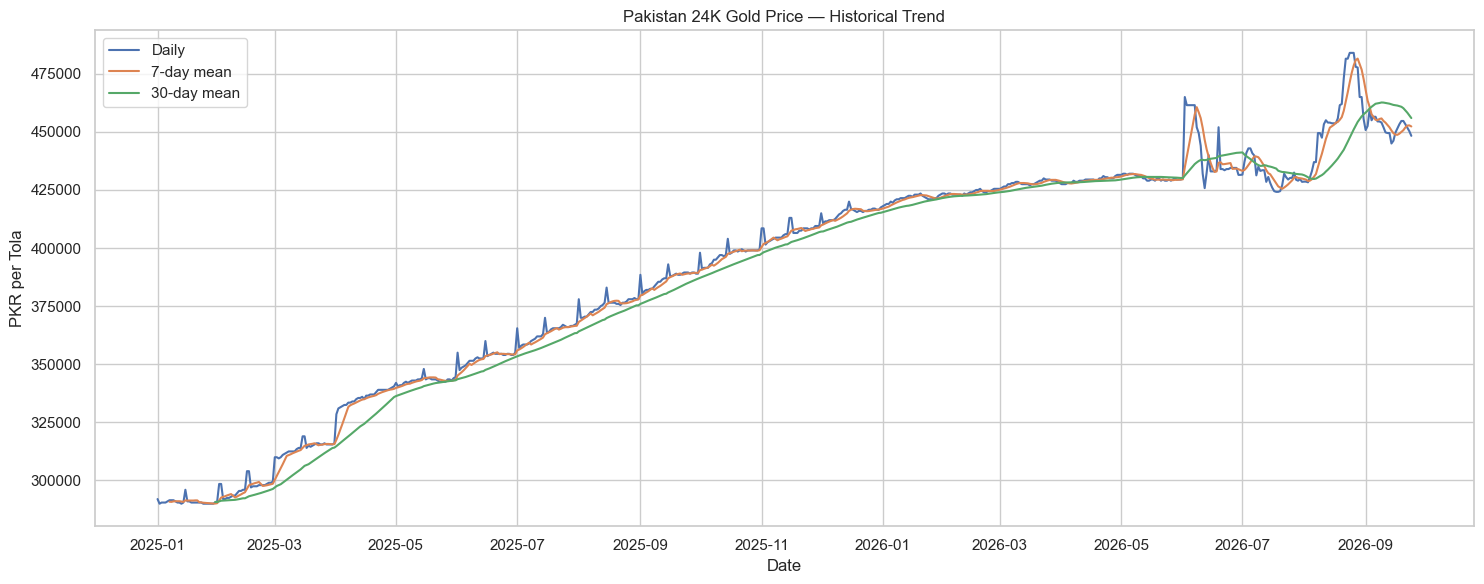

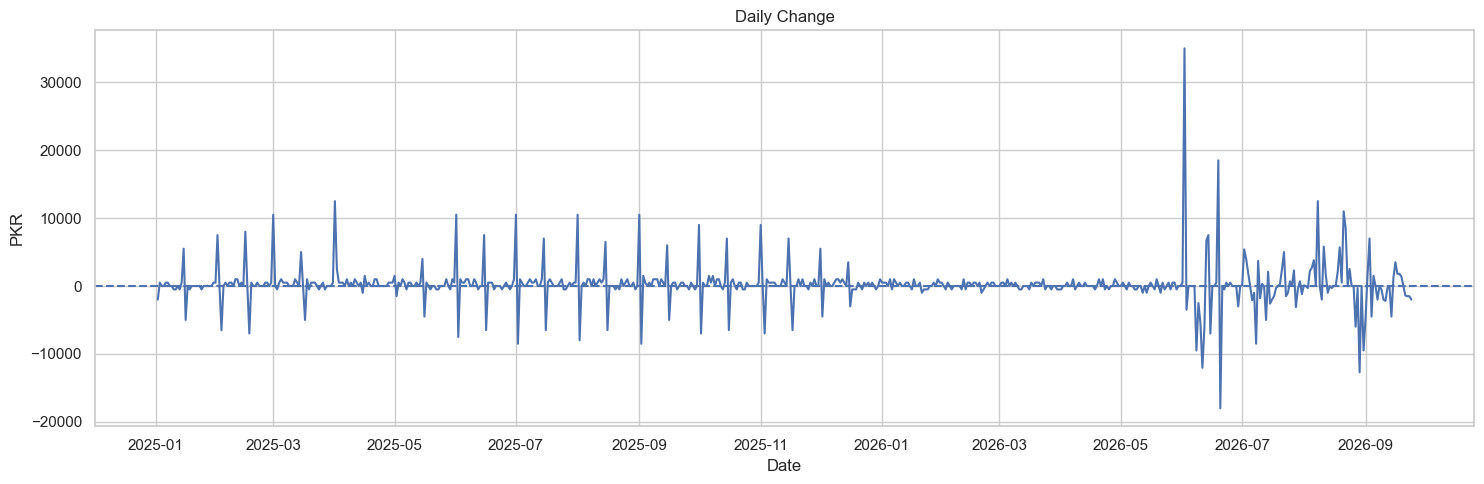

In [8]:
eda = df[["Date", TARGET]].copy()
eda["Daily_Change"] = eda[TARGET].diff()
eda["Rolling_7"] = eda[TARGET].rolling(7).mean()
eda["Rolling_30"] = eda[TARGET].rolling(30).mean()

plt.figure(figsize=(15,6))
plt.plot(eda.Date, eda[TARGET], label="Daily")
plt.plot(eda.Date, eda.Rolling_7, label="7-day mean")
plt.plot(eda.Date, eda.Rolling_30, label="30-day mean")
plt.title("Pakistan 24K Gold Price — Historical Trend")
plt.xlabel("Date"); plt.ylabel("PKR per Tola"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(15,5))
plt.plot(eda.Date, eda.Daily_Change)
plt.axhline(0, linestyle="--")
plt.title("Daily Change"); plt.xlabel("Date"); plt.ylabel("PKR"); plt.tight_layout(); plt.show()

## 8. EDA — weekday summary and correlation

,Day_of_Week_Num,Day_of_Week,count,mean,std,min,max
0,0,Monday,90,389562.222222,49732.894587,290000,484000
1,1,Tuesday,90,390313.155556,49778.174257,290000,484000
2,2,Wednesday,91,389540.021978,50437.414905,290000,484000
3,3,Thursday,91,389478.021978,50371.170772,290000,478000
4,4,Friday,90,389275.555556,50454.770737,290000,477700
5,5,Saturday,90,389814.444444,49942.127319,290000,481500
6,6,Sunday,90,390097.777778,49868.334457,290000,481500


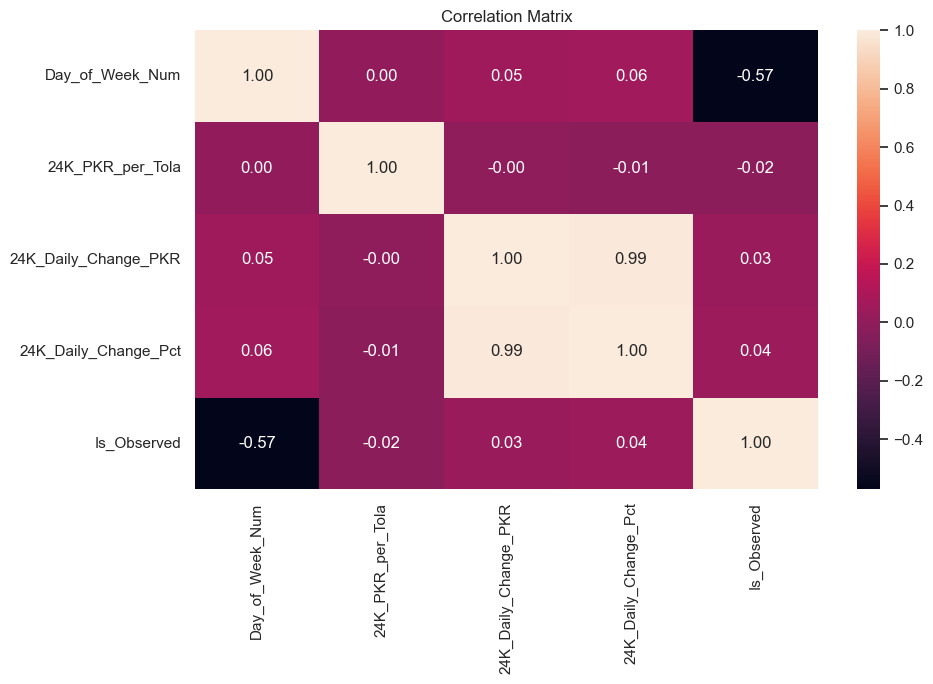

In [9]:
eda2 = df.copy()
eda2["Day_of_Week_Num"] = eda2.Date.dt.dayofweek
eda2["Day_of_Week"] = eda2.Date.dt.day_name()
display(eda2.groupby(["Day_of_Week_Num","Day_of_Week"])[TARGET].agg(["count","mean","std","min","max"]).reset_index())
plt.figure(figsize=(10,7))
sns.heatmap(eda2.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix"); plt.tight_layout(); plt.show()

## 9. Feature engineering

In [10]:
def make_features(data):
    w = data[["Date", TARGET]].copy()
    w["Date"] = pd.to_datetime(w.Date).dt.normalize()
    w = w.sort_values("Date").reset_index(drop=True)

    w["Year"] = w.Date.dt.year
    w["Month"] = w.Date.dt.month
    w["Day"] = w.Date.dt.day
    w["DayOfYear"] = w.Date.dt.dayofyear
    w["DayOfWeek"] = w.Date.dt.dayofweek
    w["WeekOfYear"] = w.Date.dt.isocalendar().week.astype(int)
    w["Quarter"] = w.Date.dt.quarter
    w["TimeIndex"] = np.arange(len(w))

    for lag in [1,2,3,7,14,21,30]:
        w[f"Lag_{lag}"] = w[TARGET].shift(lag)
    for window in [7,14,30]:
        w[f"RollingMean_{window}"] = w[TARGET].shift(1).rolling(window).mean()
        w[f"RollingStd_{window}"] = w[TARGET].shift(1).rolling(window).std()

    w["Previous_Day_Change"] = w[TARGET].shift(1).diff()
    w["Previous_Day_Change_Pct"] = w[TARGET].shift(1).pct_change()*100
    return w

feature_df = make_features(df)
feature_columns = [c for c in feature_df.columns if c not in ["Date", TARGET]]
model_df = feature_df.dropna(subset=feature_columns+[TARGET]).copy()
print("Features:", len(feature_columns), "| modeling rows:", len(model_df))
print(feature_columns)

Features: 23 | modeling rows: 602
['Year', 'Month', 'Day', 'DayOfYear', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'TimeIndex', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_21', 'Lag_30', 'RollingMean_7', 'RollingStd_7', 'RollingMean_14', 'RollingStd_14', 'RollingMean_30', 'RollingStd_30', 'Previous_Day_Change', 'Previous_Day_Change_Pct']


## 10. Chronological train / validation / test split

In [11]:
n = len(model_df)
train_end = int(n*0.70)
validation_end = int(n*0.85)

train_df = model_df.iloc[:train_end].copy()
validation_df = model_df.iloc[train_end:validation_end].copy()
test_df = model_df.iloc[validation_end:].copy()

X_train, y_train = train_df[feature_columns], train_df[TARGET]
X_validation, y_validation = validation_df[feature_columns], validation_df[TARGET]
X_test, y_test = test_df[feature_columns], test_df[TARGET]

for name, part in [("Train",train_df),("Validation",validation_df),("Test",test_df)]:
    print(name, len(part), part.Date.min().date(), "to", part.Date.max().date())

Train 421 2025-01-31 to 2026-03-27
Validation 90 2026-03-28 to 2026-06-25
Test 91 2026-06-26 to 2026-09-24


## 11. Scaling

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)
print("StandardScaler fitted on training data.")

StandardScaler fitted on training data.


## 12. Define supervised models

In [13]:
models = {
"Linear Regression": Pipeline([("scaler",StandardScaler()),("model",LinearRegression())]),
"Ridge": Pipeline([("scaler",StandardScaler()),("model",Ridge(alpha=1.0))]),
"Lasso": Pipeline([("scaler",StandardScaler()),("model",Lasso(alpha=.001,max_iter=10000))]),
"Elastic Net": Pipeline([("scaler",StandardScaler()),("model",ElasticNet(alpha=.001,l1_ratio=.5,max_iter=10000))]),
"Huber": Pipeline([("scaler",StandardScaler()),("model",HuberRegressor(max_iter=2000))]),
"RANSAC": Pipeline([("scaler",StandardScaler()),("model",RANSACRegressor(random_state=RANDOM_STATE))]),
"Poisson": Pipeline([("scaler",StandardScaler()),("model",PoissonRegressor(max_iter=2000))]),
"Decision Tree": DecisionTreeRegressor(max_depth=8,random_state=RANDOM_STATE),
"Random Forest": RandomForestRegressor(n_estimators=300,random_state=RANDOM_STATE,n_jobs=-1),
"Extra Trees": ExtraTreesRegressor(n_estimators=300,random_state=RANDOM_STATE,n_jobs=-1),
"Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
"AdaBoost": AdaBoostRegressor(n_estimators=200,random_state=RANDOM_STATE),
"KNN": Pipeline([("scaler",StandardScaler()),("model",KNeighborsRegressor(n_neighbors=5))]),
"SVR": Pipeline([("scaler",StandardScaler()),("model",SVR(C=100,epsilon=.01))]),
"Gaussian Process": Pipeline([("scaler",StandardScaler()),("model",GaussianProcessRegressor(kernel=C(1.0)*RBF(1.0),normalize_y=True,random_state=RANDOM_STATE))]),
"Quantile Regression": Pipeline([("scaler",StandardScaler()),("model",QuantileRegressor(quantile=.5,alpha=.001,solver="highs"))])
}
if importlib.util.find_spec("xgboost"):
    from xgboost import XGBRegressor
    models["XGBoost"] = XGBRegressor(n_estimators=300,max_depth=5,learning_rate=.05,subsample=.9,colsample_bytree=.9,objective="reg:squarederror",random_state=RANDOM_STATE,n_jobs=-1)
else: print("XGBoost not installed — skipped.")
if importlib.util.find_spec("catboost"):
    from catboost import CatBoostRegressor
    models["CatBoost"] = CatBoostRegressor(iterations=300,depth=6,learning_rate=.05,loss_function="RMSE",verbose=False,random_seed=RANDOM_STATE)
else: print("CatBoost not installed — skipped.")
print("Available supervised models:",len(models))

Available supervised models: 18


## 13. Evaluation metrics

In [14]:
def regression_metrics(y_true,y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mae = mean_absolute_error(y_true,y_pred)
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    nz = y_true != 0
    mape = np.mean(np.abs((y_true[nz]-y_pred[nz])/y_true[nz]))*100 if nz.any() else np.nan
    return {"MAE":mae,"RMSE":rmse,"MAPE_%":mape,"R2":r2_score(y_true,y_pred)}

## 14. Train and evaluate every supervised model

In [15]:
supervised_results, fitted_models = [], {}
for name, model in models.items():
    try:
        fitted = clone(model)
        fitted.fit(X_train,y_train)
        pv, pt = fitted.predict(X_validation), fitted.predict(X_test)
        vm, tm = regression_metrics(y_validation,pv), regression_metrics(y_test,pt)
        supervised_results.append({
            "Model":name,
            "Validation_MAE":vm["MAE"],"Validation_RMSE":vm["RMSE"],"Validation_MAPE_%":vm["MAPE_%"],"Validation_R2":vm["R2"],
            "Test_MAE":tm["MAE"],"Test_RMSE":tm["RMSE"],"Test_MAPE_%":tm["MAPE_%"],"Test_R2":tm["R2"]
        })
        fitted_models[name] = fitted
    except Exception as e:
        print(name,"failed:",e)

supervised_results_df = pd.DataFrame(supervised_results).sort_values("Validation_RMSE").reset_index(drop=True)
display(supervised_results_df)

,Model,Validation_MAE,Validation_RMSE,Validation_MAPE_%,Validation_R2,Test_MAE,Test_RMSE,Test_MAPE_%,Test_R2
0,Quantile Regression,2378.538421,5170.316732,0.538918,0.661094,3406.714345,4473.977126,0.759373,0.917984
1,Huber,2941.566986,5678.826275,0.667746,0.591152,4914.827123,5948.862129,1.097575,0.854996
2,Linear Regression,4891.407042,6997.576466,1.113739,0.379216,7520.259613,8738.931546,1.685103,0.687083
3,RANSAC,4884.577757,6999.239735,1.112176,0.378921,7451.465672,8670.934875,1.669494,0.691934
4,Lasso,5046.119311,7350.828635,1.150568,0.314957,9319.975030,10732.584632,2.092021,0.528023
5,Elastic Net,5004.694800,7512.402351,1.141605,0.284511,9072.010512,10399.110304,2.034406,0.556897
6,Poisson,5076.473589,7922.438548,1.153529,0.204275,8207.469094,10273.373397,1.824635,0.567547
7,Ridge,5371.256015,7926.264345,1.226494,0.203507,10290.733281,11551.450151,2.309661,0.453254
8,Decision Tree,4480.288889,9757.230948,0.995698,-0.206975,16980.219780,22644.388966,3.699914,-1.101037
9,Random Forest,4552.325926,9851.984115,1.011891,-0.230531,17973.315018,23676.121750,3.919470,-1.296855


## 15. Validation RMSE comparison

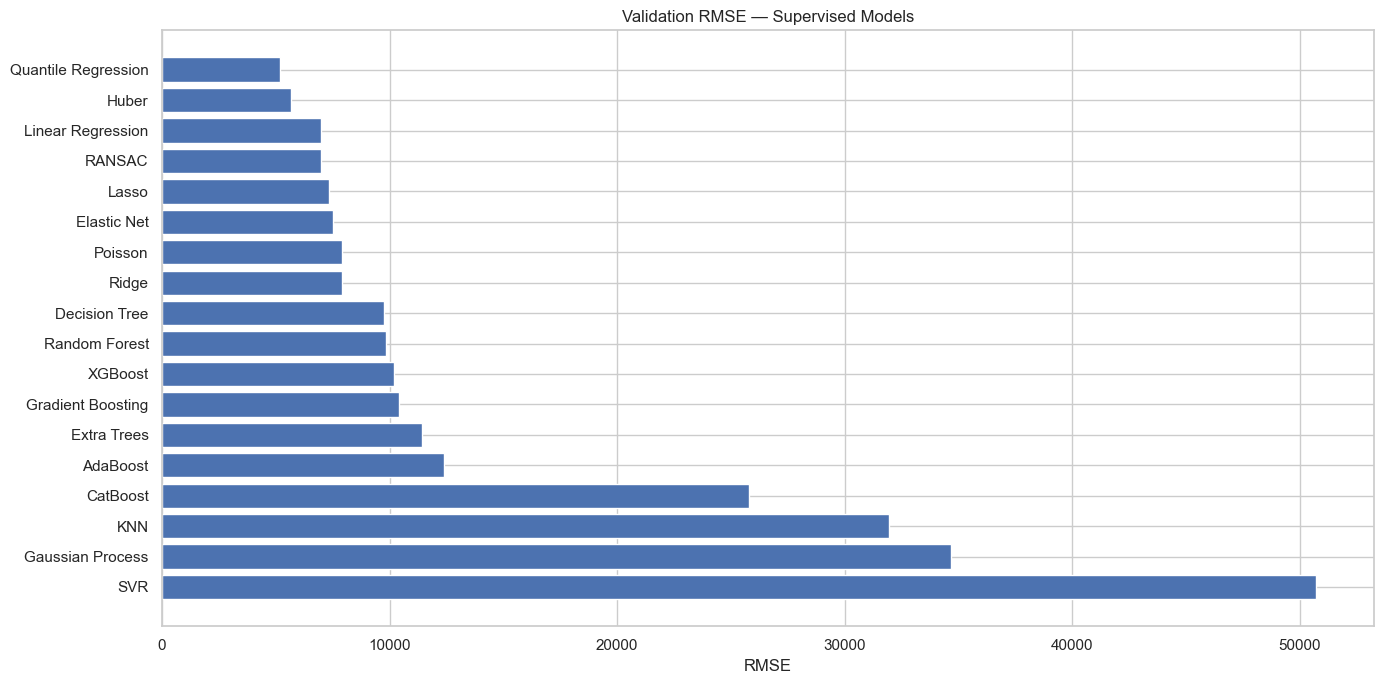

In [16]:
p = supervised_results_df.sort_values("Validation_RMSE")
plt.figure(figsize=(14,7))
plt.barh(p.Model,p.Validation_RMSE)
plt.gca().invert_yaxis()
plt.title("Validation RMSE — Supervised Models")
plt.xlabel("RMSE"); plt.tight_layout(); plt.show()

## 16. ARIMA and SARIMA

In [17]:
series = df.set_index("Date")[TARGET].asfreq("D").interpolate()
ts_train_end = int(len(series)*.85)
ts_train, ts_test = series.iloc[:ts_train_end], series.iloc[ts_train_end:]

time_series_results = []
try:
    arima = ARIMA(ts_train,order=(5,1,2)).fit()
    arima_pred = np.asarray(arima.forecast(len(ts_test)))
    m = regression_metrics(ts_test.values,arima_pred)
    time_series_results.append({"Model":"ARIMA",**m})
except Exception as e: print("ARIMA failed:",e)

try:
    sarima = SARIMAX(ts_train,order=(1,1,1),seasonal_order=(1,1,1,7),enforce_stationarity=False,enforce_invertibility=False).fit(disp=False)
    sarima_pred = np.asarray(sarima.forecast(len(ts_test)))
    m = regression_metrics(ts_test.values,sarima_pred)
    time_series_results.append({"Model":"SARIMA",**m})
except Exception as e: print("SARIMA failed:",e)

time_series_results_df = pd.DataFrame(time_series_results)
display(time_series_results_df)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


,Model,MAE,RMSE,MAPE_%,R2
0,ARIMA,14127.782171,19061.410836,3.085533,-0.518412
1,SARIMA,93835.960273,108728.876688,20.766550,-48.404836


## 17. Optional Prophet

In [18]:
if importlib.util.find_spec("prophet"):
    from prophet import Prophet
    pt = ts_train.reset_index(); pt.columns=["ds","y"]
    prophet_model = Prophet(daily_seasonality=True,weekly_seasonality=True,yearly_seasonality=False)
    prophet_model.fit(pt)
    pf = prophet_model.predict(pd.DataFrame({"ds":ts_test.index}))["yhat"].values
    m = regression_metrics(ts_test.values,pf)
    time_series_results_df = pd.concat([time_series_results_df,pd.DataFrame([{"Model":"Prophet",**m}])],ignore_index=True)
    print("Prophet completed.")
else:
    print("Prophet not installed — skipped.")

01:10:32 - cmdstanpy - INFO - Chain [1] start processing
01:10:33 - cmdstanpy - INFO - Chain [1] done processing


Prophet completed.


## 18. Optional LSTM

In [19]:
if importlib.util.find_spec("tensorflow"):
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM,Dense
    from tensorflow.keras.callbacks import EarlyStopping

    LOOKBACK=30
    vals=series.values.reshape(-1,1)
    lstm_scaler=StandardScaler()
    z=lstm_scaler.fit_transform(vals).flatten()

    def seq(values,start,end,lookback):
        X,y=[],[]
        for i in range(max(start,lookback),end):
            X.append(values[i-lookback:i]); y.append(values[i])
        return np.array(X),np.array(y)

    Xl,yl=seq(z,0,ts_train_end,LOOKBACK)
    Xt,yt=seq(z,ts_train_end,len(z),LOOKBACK)
    Xl=Xl.reshape(Xl.shape[0],Xl.shape[1],1)
    Xt=Xt.reshape(Xt.shape[0],Xt.shape[1],1)

    lstm_model=Sequential([LSTM(64,input_shape=(LOOKBACK,1)),Dense(32,activation="relu"),Dense(1)])
    lstm_model.compile(optimizer="adam",loss="mse")
    lstm_model.fit(Xl,yl,epochs=40,batch_size=16,validation_split=.1,
                   callbacks=[EarlyStopping(monitor="val_loss",patience=6,restore_best_weights=True)],verbose=0)
    lp=lstm_model.predict(Xt,verbose=0).flatten()
    lp=lstm_scaler.inverse_transform(lp.reshape(-1,1)).flatten()
    actual=ts_test.values[-len(lp):]
    m=regression_metrics(actual,lp)
    time_series_results_df=pd.concat([time_series_results_df,pd.DataFrame([{"Model":"LSTM",**m}])],ignore_index=True)
    print("LSTM completed.")
else:
    print("TensorFlow not installed — LSTM skipped.")

LSTM completed.


## 19. Time-series comparison

,Model,MAE,RMSE,MAPE_%,R2
0,LSTM,6093.643555,8848.759009,1.339306,0.672776
1,Prophet,10401.400534,13551.322392,2.314974,0.232562
2,ARIMA,14127.782171,19061.410836,3.085533,-0.518412
3,SARIMA,93835.960273,108728.876688,20.766550,-48.404836


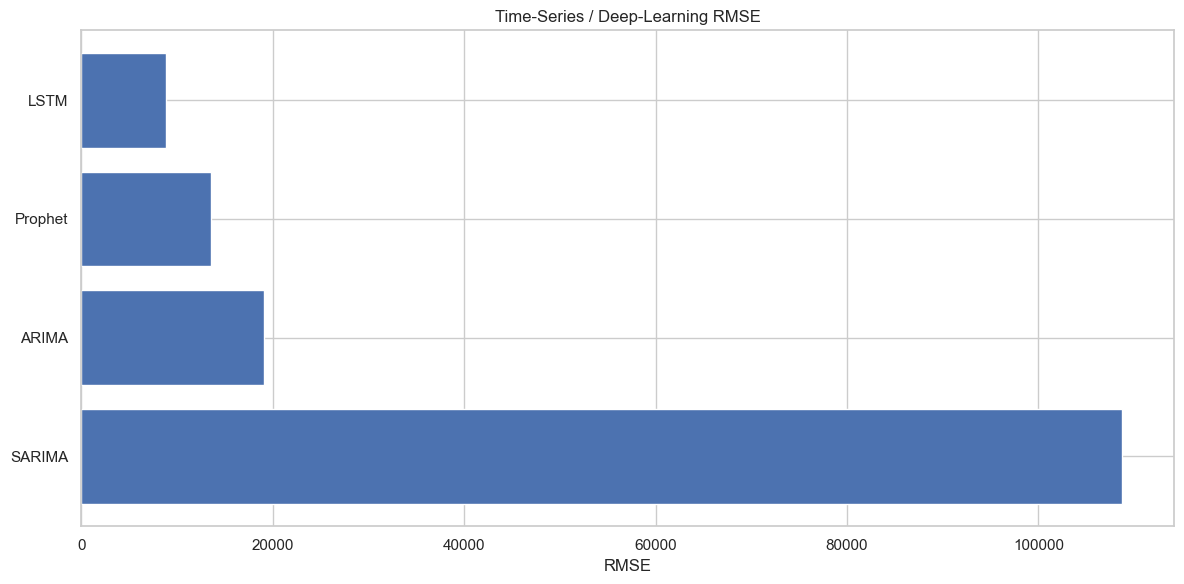

In [20]:
if not time_series_results_df.empty:
    display(time_series_results_df.sort_values("RMSE").reset_index(drop=True))
    p=time_series_results_df.sort_values("RMSE")
    plt.figure(figsize=(12,6)); plt.barh(p.Model,p.RMSE); plt.gca().invert_yaxis()
    plt.title("Time-Series / Deep-Learning RMSE"); plt.xlabel("RMSE"); plt.tight_layout(); plt.show()

## 20. Select the supervised model using validation RMSE

In [21]:
best_supervised_model_name = supervised_results_df.iloc[0].Model
final_model = fitted_models[best_supervised_model_name]
print("Selected model:",best_supervised_model_name)
print("Validation RMSE:",supervised_results_df.iloc[0].Validation_RMSE)
print("Selection uses validation data; the test set remains a holdout.")

Selected model: Quantile Regression
Validation RMSE: 5170.3167319010645
Selection uses validation data; the test set remains a holdout.


## 21. Final test result

,Model,Validation_MAE,Validation_RMSE,Validation_MAPE_%,Validation_R2,Test_MAE,Test_RMSE,Test_MAPE_%,Test_R2
0,Quantile Regression,2378.538421,5170.316732,0.538918,0.661094,3406.714345,4473.977126,0.759373,0.917984


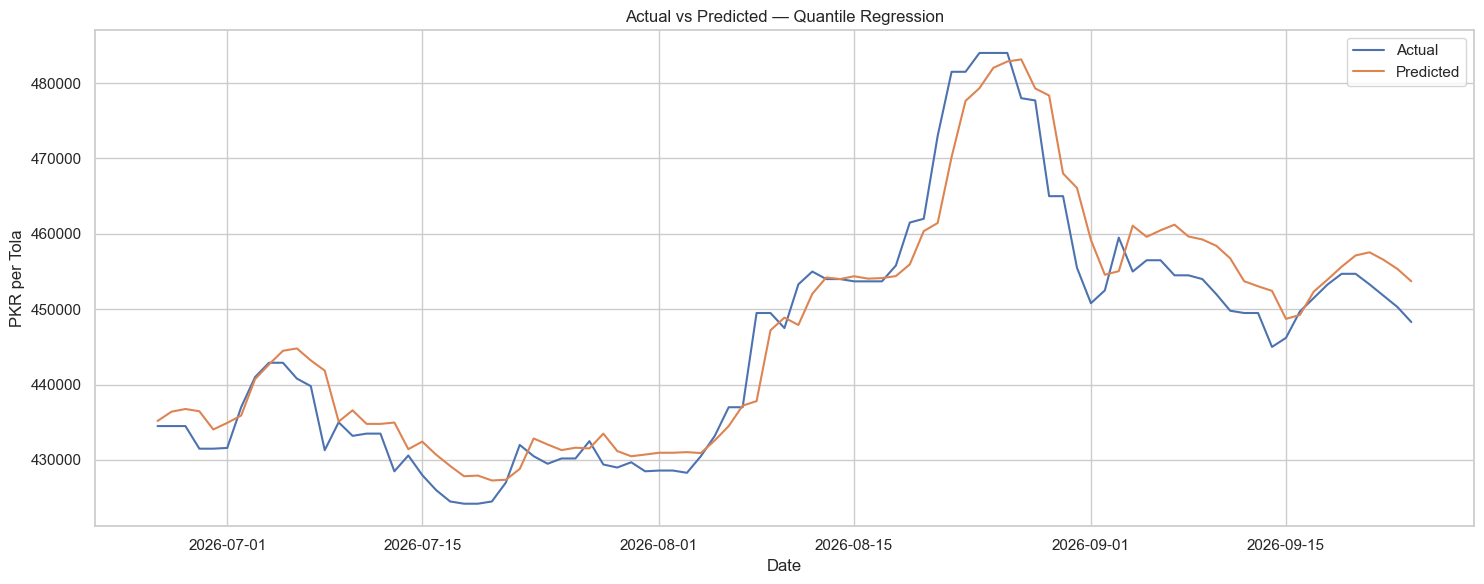

In [22]:
display(supervised_results_df[supervised_results_df.Model==best_supervised_model_name])
selected_predictions=final_model.predict(X_test)
plt.figure(figsize=(15,6))
plt.plot(test_df.Date,y_test.values,label="Actual")
plt.plot(test_df.Date,selected_predictions,label="Predicted")
plt.title(f"Actual vs Predicted — {best_supervised_model_name}")
plt.xlabel("Date"); plt.ylabel("PKR per Tola"); plt.legend(); plt.tight_layout(); plt.show()

## 22. Residual analysis

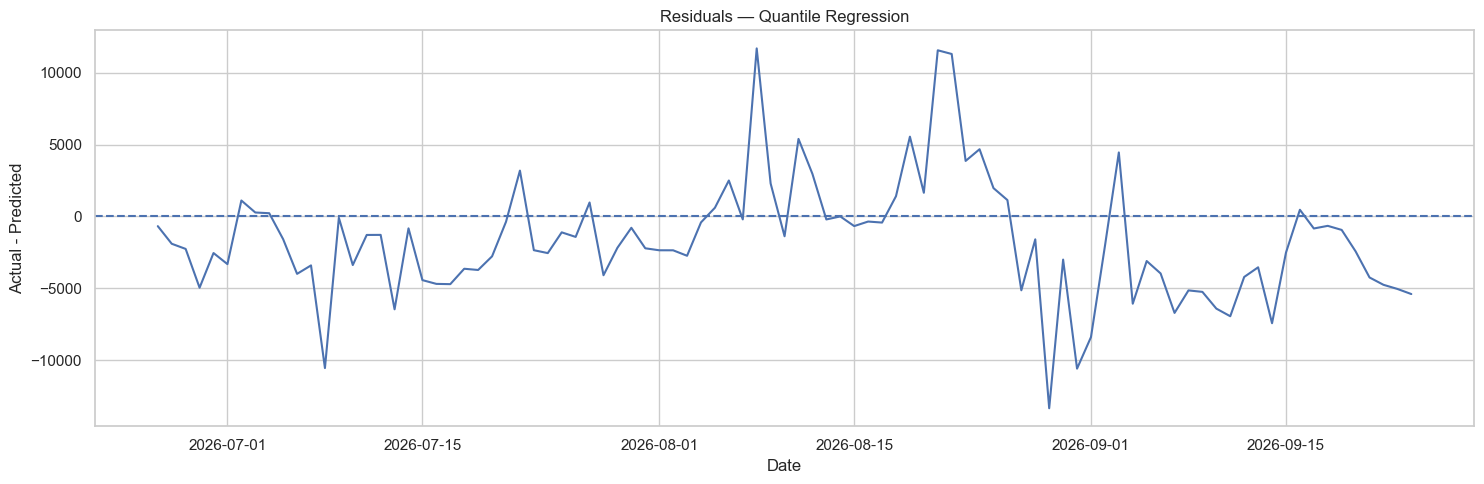

Mean residual: -1666.8183742252722
Residual std: 4151.889670469472


In [23]:
residuals=y_test.values-selected_predictions
plt.figure(figsize=(15,5)); plt.plot(test_df.Date,residuals); plt.axhline(0,linestyle="--")
plt.title(f"Residuals — {best_supervised_model_name}"); plt.xlabel("Date"); plt.ylabel("Actual - Predicted")
plt.tight_layout(); plt.show()
print("Mean residual:",residuals.mean())
print("Residual std:",residuals.std())

## 23. Retrain the selected model on all available historical observations

In [24]:
X_all,y_all=model_df[feature_columns],model_df[TARGET]
final_model_all=clone(models[best_supervised_model_name])
final_model_all.fit(X_all,y_all)
print("Retrained on",len(X_all),"observations.")

Retrained on 602 observations.


## 24. Recursive future forecasting

In [25]:
def recursive_forecast(history_df,model,feature_columns,future_dates):
    work=history_df[["Date",TARGET]].copy()
    work.Date=pd.to_datetime(work.Date).dt.normalize()
    work=work.sort_values("Date").reset_index(drop=True)
    predictions=[]

    for forecast_date in pd.DatetimeIndex(future_dates):
        temp=pd.concat([work,pd.DataFrame({"Date":[forecast_date],TARGET:[np.nan]})],ignore_index=True)
        ff=make_features(temp)
        row=ff[ff.Date==forecast_date]
        Xf=row[feature_columns]
        if Xf.empty or Xf.isna().any().any():
            raise ValueError(f"Could not construct complete features for {forecast_date.date()}.")
        pred=float(model.predict(Xf)[0])
        predictions.append({"Date":forecast_date,"Predicted_24K_PKR_per_Tola":pred})
        work=pd.concat([work,pd.DataFrame({"Date":[forecast_date],TARGET:[pred]})],ignore_index=True)
    return pd.DataFrame(predictions)

latest_actual_date=pd.to_datetime(df.Date).max().normalize()
tomorrow=latest_actual_date+pd.Timedelta(days=1)
print("Latest actual:",latest_actual_date.date())
print("Forecast starts:",tomorrow.date())

Latest actual: 2026-09-24
Forecast starts: 2026-09-25


## 25. DatePicker — choose the forecast end date

In [26]:
import ipywidgets as widgets
from IPython.display import display,clear_output

forecast_end_picker=widgets.DatePicker(description="Forecast Until:",value=(tomorrow+pd.DateOffset(months=3)).date())
run_forecast_button=widgets.Button(description="RUN FORECAST",button_style="success",icon="calendar")
forecast_output=widgets.Output()
display(forecast_end_picker,run_forecast_button,forecast_output)

DatePicker(value=datetime.date(2026, 12, 25), description='Forecast Until:', step=1)

Button(button_style='success', description='RUN FORECAST', icon='calendar', style=ButtonStyle())

Output()

## 26. Run the dynamic forecast

In [27]:
def run_dynamic_forecast(button=None):
    with forecast_output:
        clear_output()
        if forecast_end_picker.value is None:
            print("Please select an end date."); return
        end=pd.Timestamp(forecast_end_picker.value).normalize()
        if end<tomorrow:
            print("Select a date on or after",tomorrow.date()); return

        dates=pd.date_range(tomorrow,end,freq="D")
        print("Latest actual :",latest_actual_date.date())
        print("Forecast from :",tomorrow.date())
        print("Forecast until:",end.date())
        print("Forecast days :",len(dates))
        print("Selected model:",best_supervised_model_name)

        try:
            forecast_df=recursive_forecast(df,final_model_all,feature_columns,dates)
            globals()["forecast_df"]=forecast_df
            display(forecast_df)

            plt.figure(figsize=(15,6))
            plt.plot(df.Date,df[TARGET],label="Historical Price")
            plt.plot(forecast_df.Date,forecast_df.Predicted_24K_PKR_per_Tola,label=f"Forecast — {best_supervised_model_name}")
            plt.axvline(tomorrow,linestyle="--",label="Forecast Start")
            plt.title("Pakistan 24K Gold Price — Dynamic Forecast")
            plt.xlabel("Date"); plt.ylabel("PKR per Tola"); plt.legend(); plt.grid(True,alpha=.25)
            plt.tight_layout(); plt.show()
        except Exception as e:
            print("Forecast failed:",e)

run_forecast_button.on_click(run_dynamic_forecast)

## 27. Export the selected forecast to Excel

In [28]:
export_forecast_button=widgets.Button(description="EXPORT FORECAST TO EXCEL",button_style="info",icon="download")
export_output=widgets.Output()
display(export_forecast_button,export_output)

def export_forecast_click(button):
    with export_output:
        clear_output()
        if "forecast_df" not in globals() or forecast_df.empty:
            print("Run the forecast first."); return
        path=Path("Pakistan_Gold_Dynamic_Forecast.xlsx")
        with pd.ExcelWriter(path,engine="openpyxl") as writer:
            forecast_df.to_excel(writer,sheet_name="Forecast",index=False)
        print("Exported:",path.resolve())

export_forecast_button.on_click(export_forecast_click)

Button(button_style='info', description='EXPORT FORECAST TO EXCEL', icon='download', style=ButtonStyle())

Output()

## 28. Export model comparison

In [29]:
comparison_file=Path("Pakistan_Gold_Model_Comparison.xlsx")
with pd.ExcelWriter(comparison_file,engine="openpyxl") as writer:
    supervised_results_df.to_excel(writer,sheet_name="Supervised_Models",index=False)
    if not time_series_results_df.empty:
        time_series_results_df.to_excel(writer,sheet_name="Time_Series_Models",index=False)
print("Exported:",comparison_file.resolve())

Exported: G:\Saylani\ML\Pakistan_Gold_Model_Comparison.xlsx


## 29. Notes and limitations

- Gold.pk is checked for the latest daily closing rate. If the site cannot be reached or its table structure changes, the existing Excel dataset is preserved.
- Duplicate dates are not added.
- Forecasting starts at **latest actual date + 1 day**.
- The DatePicker changes only the forecast horizon; it does not require retraining.
- Model selection uses **validation RMSE**. The test set is retained for final evaluation.
- The selected supervised model is retrained on all available historical rows before future forecasting.
- Recursive forecasts feed each prediction back into the lag/rolling features for the following day.
- The forecast is based on historical gold-price-derived features. It does not automatically include future USD/PKR, international gold, interest rates, geopolitical events, or other external drivers.
- Optional XGBoost, CatBoost, Prophet, and LSTM models are included when their packages are available.